# llama.cpp benchmark plots from generated CSVs

This notebook **does not rediscover or parse benchmark result folders**. It uses the CSVs created by `analysis.ipynb`:

- `all_runs_with_prompt_level_mean_std.csv`
- `configuration_category_and_overall_mean_std.csv`

It creates the requested plots and writes them as PNG files into `ROOT_DIR / "analysis_exports" / "plots"`.

Metric note: the source benchmark records visible stdout byte events, so TPOT and throughput are event-based unless the benchmark implementation is changed to collect real token timings.

In [97]:
from pathlib import Path

# Change only this path for your run.
ROOT_DIR = Path("data/experiments-x86")

EXPORT_DIR = ROOT_DIR / "analysis_exports"
ALL_RUNS_CSV = EXPORT_DIR / "all_runs_with_response.csv"
GROUPED_CSV = EXPORT_DIR / "configuration_category_and_overall_mean_std.csv"
PLOTS_DIR = EXPORT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT_DIR   = {ROOT_DIR.resolve()}")
print(f"EXPORT_DIR = {EXPORT_DIR.resolve()}")
print(f"PLOTS_DIR  = {PLOTS_DIR.resolve()}")
print(f"All-runs CSV exists: {ALL_RUNS_CSV.exists()} -> {ALL_RUNS_CSV}")
print(f"Grouped CSV exists:  {GROUPED_CSV.exists()} -> {GROUPED_CSV}")

ROOT_DIR   = C:\Users\morit\OneDrive - TU Wien\Dokumente\Informatik\SS26\BDA\Inference\data\experiments-x86
EXPORT_DIR = C:\Users\morit\OneDrive - TU Wien\Dokumente\Informatik\SS26\BDA\Inference\data\experiments-x86\analysis_exports
PLOTS_DIR  = C:\Users\morit\OneDrive - TU Wien\Dokumente\Informatik\SS26\BDA\Inference\data\experiments-x86\analysis_exports\plots
All-runs CSV exists: True -> data\experiments-x86\analysis_exports\all_runs_with_response.csv
Grouped CSV exists:  True -> data\experiments-x86\analysis_exports\configuration_category_and_overall_mean_std.csv


In [98]:
import warnings
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

if not ALL_RUNS_CSV.exists():
    raise FileNotFoundError(
        f"Missing {ALL_RUNS_CSV}. Run scripts/export_runs_with_response.py first."
    )
if not GROUPED_CSV.exists():
    raise FileNotFoundError(
        f"Missing {GROUPED_CSV}. Run scripts/export_runs_with_response.py first to generate grouped summaries."
    )

runs = pd.read_csv(ALL_RUNS_CSV)
grouped = pd.read_csv(GROUPED_CSV)

if "peak_rss_mb" not in runs.columns and "memory_peak_mb" in runs.columns:
    runs["peak_rss_mb"] = runs["memory_peak_mb"]

# Normalize numeric columns in case CSV readers imported them as strings.
NUMERIC_COLUMNS = [
    "configuration_value", "ttft_s", "tpot_s", "prompt_tps", "generation_tps", "peak_rss_mb",
    "memory_peak_mb",
    "ttft_s_mean", "ttft_s_std", "tpot_s_mean", "tpot_s_std",
    "prompt_tps_mean", "prompt_tps_std", "generation_tps_mean", "generation_tps_std",
    "peak_rss_mb_mean", "peak_rss_mb_std",
]
for df in (runs, grouped):
    for col in NUMERIC_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded all runs: {runs.shape[0]:,} rows × {runs.shape[1]:,} columns")
print(f"Loaded grouped summary: {grouped.shape[0]:,} rows × {grouped.shape[1]:,} columns")

display(grouped[[c for c in ["configuration_group", "configuration_label", "category", "n_observations", "n_prompts"] if c in grouped.columns]].head(20))

Loaded all runs: 958 rows × 31 columns
Loaded grouped summary: 50 rows × 23 columns


,configuration_group,configuration_label,category,n_observations,n_prompts
0,concurrency,concurrency=2,short,20,10
1,concurrency,concurrency=2,medium,20,10
2,concurrency,concurrency=2,long,22,11
3,concurrency,concurrency=2,overall,62,31
4,concurrency,concurrency=4,short,40,10
5,concurrency,concurrency=4,medium,40,10
6,concurrency,concurrency=4,long,44,11
7,concurrency,concurrency=4,overall,124,31
8,concurrency,concurrency=16,short,16,1
9,concurrency,concurrency=16,overall,16,1


## Helper functions

In [99]:
CATEGORIES = ["short", "medium", "long"]
CATEGORY_COLORS = {
    "short": "tab:blue",
    "medium": "tab:orange",
    "long": "tab:green",
}

def _sort_by_x(df: pd.DataFrame, x_col: str) -> pd.DataFrame:
    return df.sort_values(x_col, kind="stable").reset_index(drop=True)


def _require_columns(df: pd.DataFrame, cols: Iterable[str], context: str) -> bool:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        warnings.warn(f"Skipping {context}; missing columns: {missing}")
        return False
    return True


def save_current_plot(filename: str) -> Path:
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved {path}")
    return path


def grouped_overall(group_name: str) -> pd.DataFrame:
    # Return overall rows for one configuration group from the grouped CSV.
    if not _require_columns(grouped, ["configuration_group", "category"], "grouped_overall"):
        return pd.DataFrame()
    df = grouped[(grouped["configuration_group"] == group_name) & (grouped["category"] == "overall")].copy()
    return _sort_by_x(df, "configuration_value") if "configuration_value" in df.columns else df


def grouped_by_category(group_name: str, category: str) -> pd.DataFrame:
    if not _require_columns(grouped, ["configuration_group", "category"], "grouped_by_category"):
        return pd.DataFrame()
    df = grouped[(grouped["configuration_group"] == group_name) & (grouped["category"] == category)].copy()
    return _sort_by_x(df, "configuration_value") if "configuration_value" in df.columns else df


def _filter_categories(group_name: str) -> pd.DataFrame:
    if not _require_columns(grouped, ["configuration_group", "category"], "filter_categories"):
        return pd.DataFrame()
    df = grouped[
        (grouped["configuration_group"] == group_name)
        & (grouped["category"].isin(CATEGORIES))
    ].copy()
    return _sort_by_x(df, "configuration_value") if "configuration_value" in df.columns else df


def _collect_xticks(group_name: str) -> list[float]:
    overall = grouped_overall(group_name)
    if overall.empty or "configuration_value" not in overall.columns:
        return []
    values = overall["configuration_value"].dropna().unique().tolist()
    return sorted(values)


def display_plot_table(title: str, df: pd.DataFrame, cols: list[str]) -> None:
    print(title)
    cols = [c for c in cols if c in df.columns]
    if df.empty or not cols:
        print("No data.")
        return
    display(df[cols])


def errorbar_plot(df: pd.DataFrame, x_col: str, y_mean: str, y_std: str, xlabel: str, ylabel: str, title: str, filename: str) -> Optional[Path]:
    needed = [x_col, y_mean, y_std]
    if not _require_columns(df, needed, title):
        return None
    plot_df = df.dropna(subset=[x_col, y_mean]).copy()
    if plot_df.empty:
        warnings.warn(f"Skipping {title}; no rows after dropping missing x/y values.")
        return None
    plot_df = _sort_by_x(plot_df, x_col)

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        plot_df[x_col],
        plot_df[y_mean],
        yerr=plot_df[y_std].fillna(0),
        marker="o",
        capsize=4,
        linestyle="-",
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    return save_current_plot(filename)


def errorbar_plot_multi(group_name: str, x_col: str, y_mean: str, y_std: str, xlabel: str, ylabel: str, title: str, filename: str, categories: list[str] = CATEGORIES) -> Optional[Path]:
    if not _require_columns(grouped, ["configuration_group", "category"], title):
        return None
    plt.figure(figsize=(8, 5))
    plotted = False
    xticks = _collect_xticks(group_name)
    for category in categories:
        df = grouped_by_category(group_name, category)
        if df.empty:
            print(f"No {group_name} rows for category '{category}'; skipping.")
            continue
        plot_df = df.dropna(subset=[x_col, y_mean]).copy()
        if plot_df.empty:
            print(f"No {group_name} rows for category '{category}' after dropna; skipping.")
            continue
        plot_df = _sort_by_x(plot_df, x_col)
        color = CATEGORY_COLORS.get(category)
        plt.errorbar(
            plot_df[x_col],
            plot_df[y_mean],
            yerr=plot_df[y_std].fillna(0),
            marker="o",
            capsize=4,
            linestyle="-",
            label=category,
            color=color,
        )
        plotted = True
    if not plotted:
        warnings.warn(f"Skipping {title}; no category data.")
        return None
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Category")
    if xticks:
        plt.xticks(xticks)
    return save_current_plot(filename)

## Plot 1: Throughput vs. thread count

Uses `configuration_category_and_overall_mean_std.csv`, filtered to `configuration_group == "threads"` and `category == "overall"`. Error bars are standard deviations from the grouped CSV.

,configuration_group,configuration_name,configuration_value,configuration_label,category,n_observations,n_prompts,n_workers,ttft_s_mean,ttft_s_std,ttft_s_mean_pm_std,tpot_s_mean,tpot_s_std,tpot_s_mean_pm_std,prompt_tps_mean,prompt_tps_std,prompt_tps_mean_pm_std,generation_tps_mean,generation_tps_std,generation_tps_mean_pm_std,peak_rss_mb_mean,peak_rss_mb_std,peak_rss_mb_mean_pm_std
0,threads,threads,4,threads=4,overall,93,31,0,3.769500,0.931510,3.769500 +/- 0.931510,0.058430,0.001060,0.058430 +/- 0.001060,45.998925,11.063930,45.998925 +/- 11.063930,17.120430,0.327892,17.120430 +/- 0.327892,3549.173639,172.370023,3549.173639 +/- 172.370023
1,threads,threads,16,threads=16,overall,93,31,0,3.148128,0.679026,3.148128 +/- 0.679026,0.049342,0.000702,0.049342 +/- 0.000702,94.769892,54.372717,94.769892 +/- 54.372717,20.270968,0.301655,20.270968 +/- 0.301655,3556.437080,177.406660,3556.437080 +/- 177.406660
2,threads,threads,64,threads=64,overall,93,31,0,3.055105,0.619124,3.055105 +/- 0.619124,0.058510,0.001421,0.058510 +/- 0.001421,114.341935,74.429970,114.341935 +/- 74.429970,17.102151,0.457065,17.102151 +/- 0.457065,3561.375630,178.114895,3561.375630 +/- 178.114895
3,threads,threads,128,threads=128,overall,93,31,0,3.279987,0.564210,3.279987 +/- 0.564210,0.167275,0.011545,0.167275 +/- 0.011545,64.643011,18.058290,64.643011 +/- 18.058290,6.004301,0.383891,6.004301 +/- 0.383891,3568.020833,180.517425,3568.020833 +/- 180.517425


Threads - generation throughput (t/s)


,configuration_value,category,generation_tps_mean,generation_tps_std
0,4,short,17.396667,0.424657
1,4,medium,17.123333,0.050401
2,4,long,16.866667,0.073598
3,16,short,20.523333,0.390122
4,16,medium,20.276667,0.062606
5,16,long,20.036364,0.060302
6,64,short,17.360000,0.687123
7,64,medium,17.166667,0.102833
8,64,long,16.809091,0.091391
9,128,short,5.723333,0.267406


Saved data\experiments-x86\analysis_exports\plots\generation_tps_vs_thread_count.png
Threads - prompt processing throughput (t/s)


,configuration_value,category,prompt_tps_mean,prompt_tps_std
0,4,short,55.700000,10.064310
1,4,medium,35.676667,8.615811
2,4,long,46.563636,2.101312
3,16,short,156.116667,43.246775
4,16,medium,57.353333,39.706846
5,16,long,73.015152,6.862175
6,64,short,197.990000,62.306729
7,64,medium,65.260000,52.520824
8,64,long,82.918182,8.514893
9,128,short,68.876667,18.185570


Saved data\experiments-x86\analysis_exports\plots\prompt_tps_vs_thread_count.png
Threads - peak memory usage (MB)


,configuration_value,category,peak_rss_mb_mean,peak_rss_mb_std
0,4,short,3336.419792,108.423699
1,4,medium,3624.410026,109.425340
2,4,long,3674.189512,7.490029
3,16,short,3339.349479,107.450212
4,16,medium,3627.726562,110.402874
5,16,long,3688.980824,43.737869
6,64,short,3342.130078,105.600339
7,64,medium,3636.469661,119.732635
8,64,long,3692.422467,7.092535
9,128,short,3345.404818,103.189783


Saved data\experiments-x86\analysis_exports\plots\peak_memory usage_vs_thread_count.png


WindowsPath('data/experiments-x86/analysis_exports/plots/peak_memory usage_vs_thread_count.png')

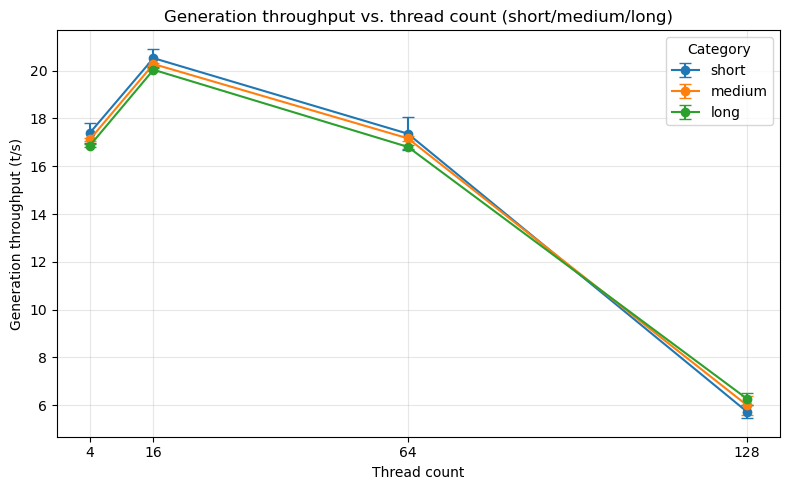

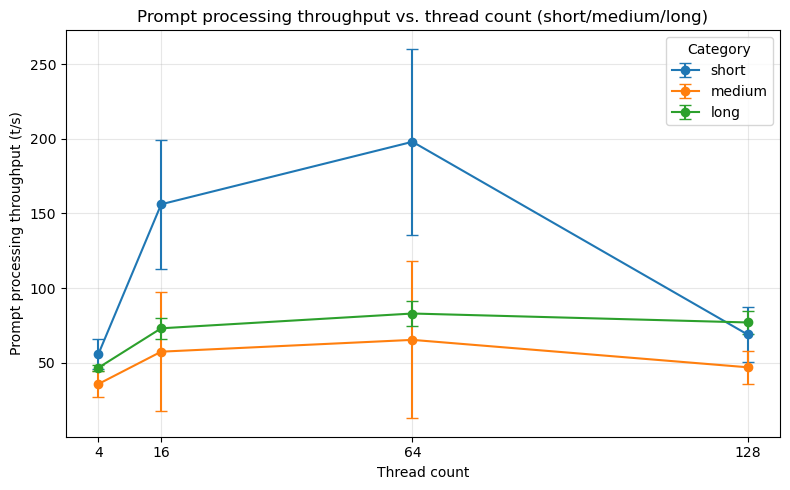

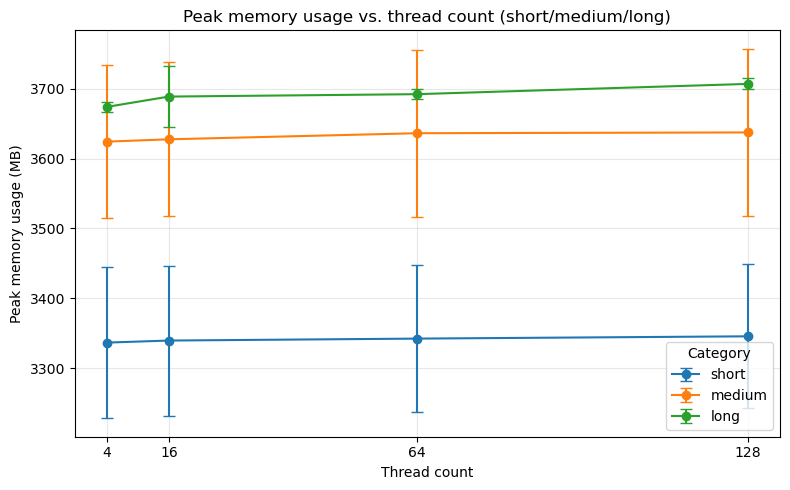

In [108]:
threads_overall = grouped_overall("threads")
display(threads_overall)

threads_cat = _filter_categories("threads")
display_plot_table(
    "Threads - generation throughput (t/s)",
    threads_cat,
    ["configuration_value", "category", "generation_tps_mean", "generation_tps_std"],
)
errorbar_plot_multi(
    "threads",
    x_col="configuration_value",
    y_mean="generation_tps_mean",
    y_std="generation_tps_std",
    xlabel="Thread count",
    ylabel="Generation throughput (t/s)",
    title="Generation throughput vs. thread count (short/medium/long)",
    filename="generation_tps_vs_thread_count.png",
)

display_plot_table(
    "Threads - prompt processing throughput (t/s)",
    threads_cat,
    ["configuration_value", "category", "prompt_tps_mean", "prompt_tps_std"],
)
errorbar_plot_multi(
    "threads",
    x_col="configuration_value",
    y_mean="prompt_tps_mean",
    y_std="prompt_tps_std",
    xlabel="Thread count",
    ylabel="Prompt processing throughput (t/s)",
    title="Prompt processing throughput vs. thread count (short/medium/long)",
    filename="prompt_tps_vs_thread_count.png",
)

display_plot_table(
    "Threads - peak memory usage (MB)",
    threads_cat,
    ["configuration_value", "category", "peak_rss_mb_mean", "peak_rss_mb_std"],
)
errorbar_plot_multi(
    "threads",
    x_col="configuration_value",
    y_mean="peak_rss_mb_mean",
    y_std="peak_rss_mb_std",
    xlabel="Thread count",
    ylabel="Peak memory usage (MB)",
    title="Peak memory usage vs. thread count (short/medium/long)",
    filename="peak_memory usage_vs_thread_count.png",
)

## Optional companion: Throughput vs. concurrency

This is useful because your experiment runner also has a concurrency configuration group. It is generated only if concurrency rows exist in the CSV.

,configuration_group,configuration_name,configuration_value,configuration_label,category,n_observations,n_prompts,n_workers,ttft_s_mean,ttft_s_std,ttft_s_mean_pm_std,tpot_s_mean,tpot_s_std,tpot_s_mean_pm_std,prompt_tps_mean,prompt_tps_std,prompt_tps_mean_pm_std,generation_tps_mean,generation_tps_std,generation_tps_mean_pm_std,peak_rss_mb_mean,peak_rss_mb_std,peak_rss_mb_mean_pm_std
0,concurrency,concurrency,2,concurrency=2,overall,62,31,2,8.297565,2.297441,8.297565 +/- 2.297441,0.183516,0.010846,0.183516 +/- 0.010846,22.351613,7.705964,22.351613 +/- 7.705964,5.467742,0.320744,5.467742 +/- 0.320744,3548.957787,172.172852,3548.957787 +/- 172.172852
1,concurrency,concurrency,4,concurrency=4,overall,124,31,4,21.840424,5.363739,21.840424 +/- 5.363739,1.465873,0.283754,1.465873 +/- 0.283754,6.570968,3.896001,6.570968 +/- 3.896001,0.775806,0.671168,0.775806 +/- 0.671168,3551.598034,172.959839,3551.598034 +/- 172.959839
2,concurrency,concurrency,16,concurrency=16,overall,16,1,16,201.446999,19.224167,201.446999 +/- 19.224167,NaN,NaN,NaN,0.156250,0.051235,0.156250 +/- 0.051235,0.000000,0.000000,0.000000 +/- 0.000000,3300.910889,1.901222,3300.910889 +/- 1.901222


Concurrency - generation throughput (t/s)


,configuration_value,category,generation_tps_mean,generation_tps_std
0,2,short,5.490000,0.255260
1,2,medium,5.540000,0.325091
2,2,long,5.381818,0.362053
3,4,short,0.690000,0.100766
4,4,medium,0.787500,0.147087
5,4,long,0.843182,1.117180
6,16,short,0.000000,0.000000


Saved data\experiments-x86\analysis_exports\plots\generation_tps_vs_concurrency.png
Concurrency - prompt processing throughput (t/s)


,configuration_value,category,prompt_tps_mean,prompt_tps_std
0,2,short,24.835000,8.372152
1,2,medium,18.410000,8.755143
2,2,long,23.677273,4.148428
3,4,short,5.600000,5.237194
4,4,medium,5.475000,2.105640
5,4,long,8.450000,2.985508
6,16,short,0.156250,0.051235


Saved data\experiments-x86\analysis_exports\plots\prompt_tps_vs_concurrency.png


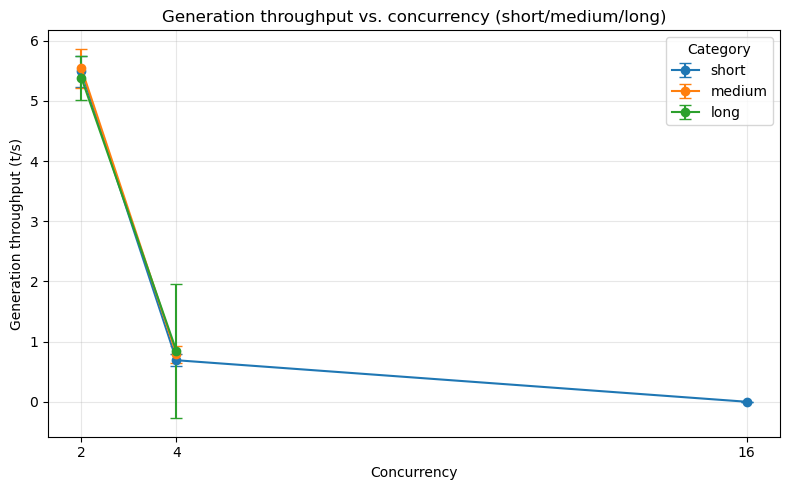

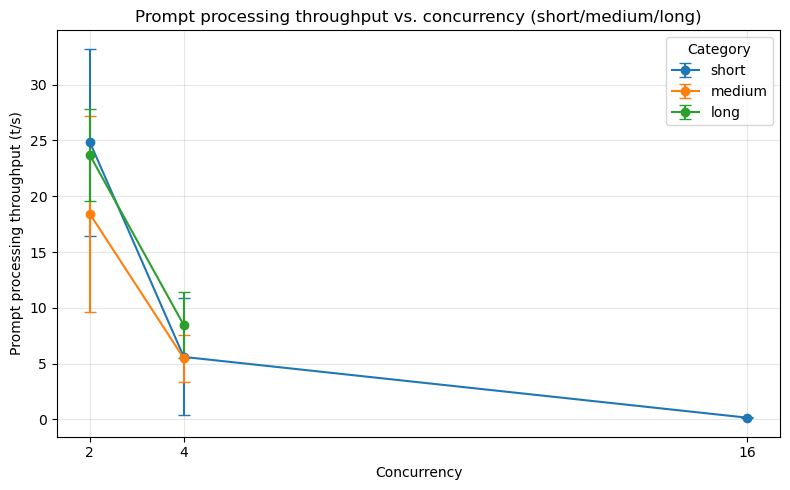

In [101]:
concurrency_overall = grouped_overall("concurrency")
if concurrency_overall.empty:
    print("No concurrency rows found; skipping throughput vs. concurrency.")
else:
    display(concurrency_overall)
    concurrency_cat = _filter_categories("concurrency")
    display_plot_table(
        "Concurrency - generation throughput (t/s)",
        concurrency_cat,
        ["configuration_value", "category", "generation_tps_mean", "generation_tps_std"],
    )
    errorbar_plot_multi(
        "concurrency",
        x_col="configuration_value",
        y_mean="generation_tps_mean",
        y_std="generation_tps_std",
        xlabel="Concurrency",
        ylabel="Generation throughput (t/s)",
        title="Generation throughput vs. concurrency (short/medium/long)",
        filename="generation_tps_vs_concurrency.png",
    )
    display_plot_table(
        "Concurrency - prompt processing throughput (t/s)",
        concurrency_cat,
        ["configuration_value", "category", "prompt_tps_mean", "prompt_tps_std"],
    )
    errorbar_plot_multi(
        "concurrency",
        x_col="configuration_value",
        y_mean="prompt_tps_mean",
        y_std="prompt_tps_std",
        xlabel="Concurrency",
        ylabel="Prompt processing throughput (t/s)",
        title="Prompt processing throughput vs. concurrency (short/medium/long)",
        filename="prompt_tps_vs_concurrency.png",
    )

## Plot 2: TTFT vs. prompt length

For the existing experiment output, prompt length comes from the context-length configuration value, named `target_context_tokens≈N` in the aggregation. These context prompts are synthetic approximate context lengths.

,configuration_group,configuration_name,configuration_value,configuration_label,category,n_observations,n_prompts,n_workers,ttft_s_mean,ttft_s_std,ttft_s_mean_pm_std,tpot_s_mean,tpot_s_std,tpot_s_mean_pm_std,prompt_tps_mean,prompt_tps_std,prompt_tps_mean_pm_std,generation_tps_mean,generation_tps_std,generation_tps_mean_pm_std,peak_rss_mb_mean,peak_rss_mb_std,peak_rss_mb_mean_pm_std
0,context_length,target_context_tokens_approx,32,target_context_tokens_approx=32,overall,3,1,0,3.707539,0.670432,3.707539 +/- 0.670432,0.049181,0.000139,0.049181 +/- 0.000139,43.400000,1.824829,43.400000 +/- 1.824829,20.333333,0.057735,20.333333 +/- 0.057735,3005.511719,1.099448,3005.511719 +/- 1.099448
1,context_length,target_context_tokens_approx,128,target_context_tokens_approx=128,overall,3,1,0,3.706868,0.038514,3.706868 +/- 0.038514,0.049917,0.000144,0.049917 +/- 0.000144,80.866667,1.850225,80.866667 +/- 1.850225,20.033333,0.057735,20.033333 +/- 0.057735,3060.404948,11.021442,3060.404948 +/- 11.021442
2,context_length,target_context_tokens_approx,512,target_context_tokens_approx=512,overall,3,1,0,5.117055,0.034972,5.117055 +/- 0.034972,0.050848,0.000150,0.050848 +/- 0.000150,153.666667,1.724336,153.666667 +/- 1.724336,19.666667,0.057735,19.666667 +/- 0.057735,3141.505208,0.970020,3141.505208 +/- 0.970020
3,context_length,target_context_tokens_approx,2048,target_context_tokens_approx=2048,overall,3,1,0,15.332345,0.038104,15.332345 +/- 0.038104,0.055659,0.000179,0.055659 +/- 0.000179,141.633333,0.461880,141.633333 +/- 0.461880,17.966667,0.057735,17.966667 +/- 0.057735,3451.649740,1.243270,3451.649740 +/- 1.243270


Context length - TTFT (overall)


,configuration_value,ttft_s_mean,ttft_s_std
0,32,3.707539,0.670432
1,128,3.706868,0.038514
2,512,5.117055,0.034972
3,2048,15.332345,0.038104


Saved data\experiments-x86\analysis_exports\plots\ttft_vs_prompt_length.png
Context length - peak RSS (MB)


,configuration_value,category,peak_rss_mb_mean,peak_rss_mb_std
0,32,short,3005.511719,1.099448
1,128,short,3060.404948,11.021442
2,512,medium,3141.505208,0.970020
3,2048,long,3451.649740,1.243270


Saved data\experiments-x86\analysis_exports\plots\peak_rss_vs_prompt_length.png


WindowsPath('data/experiments-x86/analysis_exports/plots/peak_rss_vs_prompt_length.png')

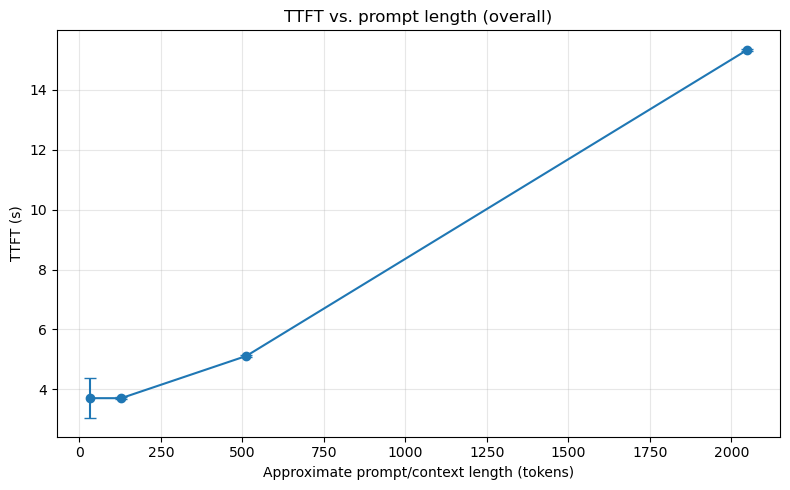

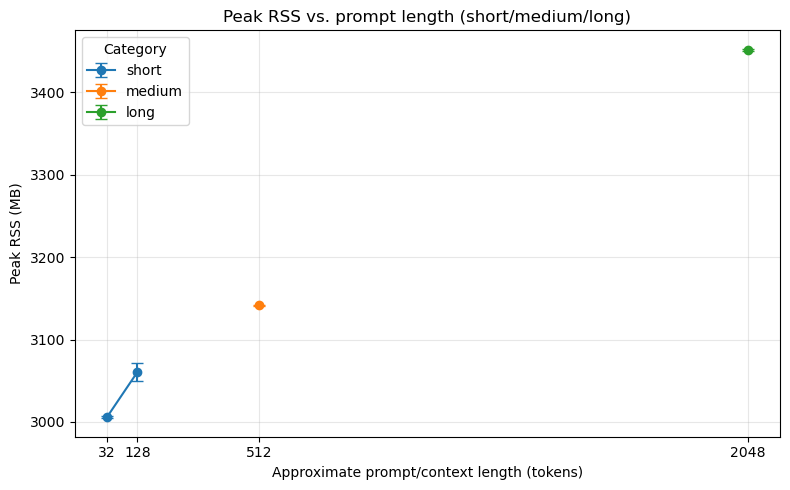

In [102]:
context_overall = grouped_overall("context_length")
display(context_overall)

display_plot_table(
    "Context length - TTFT (overall)",
    context_overall,
    ["configuration_value", "ttft_s_mean", "ttft_s_std"],
)
errorbar_plot(
    context_overall,
    x_col="configuration_value",
    y_mean="ttft_s_mean",
    y_std="ttft_s_std",
    xlabel="Approximate prompt/context length (tokens)",
    ylabel="TTFT (s)",
    title="TTFT vs. prompt length (overall)",
    filename="ttft_vs_prompt_length.png",
)

context_cat = _filter_categories("context_length")
display_plot_table(
    "Context length - peak RSS (MB)",
    context_cat,
    ["configuration_value", "category", "peak_rss_mb_mean", "peak_rss_mb_std"],
)
errorbar_plot_multi(
    "context_length",
    x_col="configuration_value",
    y_mean="peak_rss_mb_mean",
    y_std="peak_rss_mb_std",
    xlabel="Approximate prompt/context length (tokens)",
    ylabel="Peak RSS (MB)",
    title="Peak RSS vs. prompt length (short/medium/long)",
    filename="peak_rss_vs_prompt_length.png",
)

## Plot 3: TPOT vs thread count and decode length

These plots compare observed TPOT against a constant bandwidth-bound prediction:

$$TPOT_{pred} = \frac{model\_size\_MB}{DRAM\_bandwidth\_MB/s}$$

The predicted TPOT is a straight horizontal line. We plot it against thread count and decode length,
with observed TPOT per category (short/medium/long).

Using model_size_mb=1710.000 MB -> predicted_tpot_s=0.061071 s/token
Saved predictions to data\experiments-x86\analysis_exports\plots\tpot_predictions.csv
Decode length - peak RSS (MB)


,configuration_value,category,peak_rss_mb_mean,peak_rss_mb_std
0,32,short,3340.180078,107.449487
1,32,medium,3626.613542,110.191719
2,32,long,3679.889441,6.394161
3,128,short,3339.733854,108.075543
4,128,medium,3627.511849,109.550270
5,128,long,3679.814157,4.885460
6,512,short,3339.200260,108.185553
7,512,medium,3628.320833,109.257574
8,512,long,3681.209399,5.829308
9,2048,short,3340.058333,107.225814


Saved data\experiments-x86\analysis_exports\plots\peak_rss_vs_decode_length.png


WindowsPath('data/experiments-x86/analysis_exports/plots/peak_rss_vs_decode_length.png')

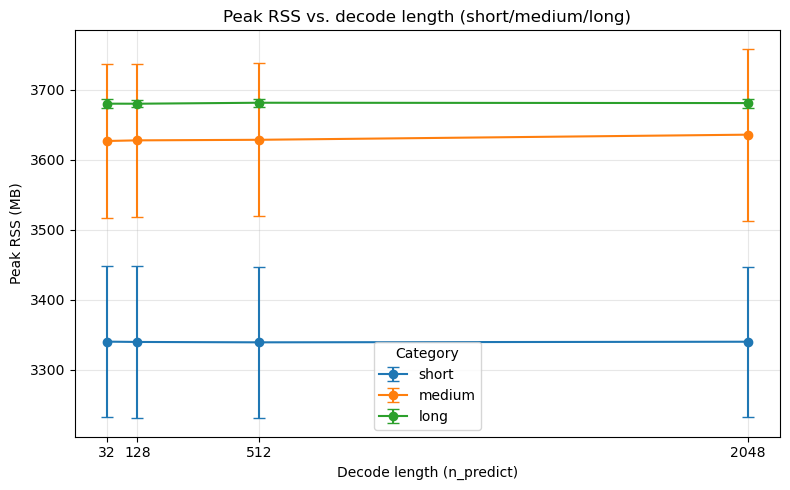

In [ ]:
import json

DRAM_BANDWIDTH_MB_S = 28000.0
MODEL_SIZE_MB_OVERRIDE = 1710  # Set to a float to force a constant model size (MB).

def _parse_command_model_path(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return None
        try:
            parsed = json.loads(text)
        except Exception:
            return None
    else:
        parsed = value
    if not isinstance(parsed, list):
        return None
    if "-m" not in parsed:
        return None
    idx = parsed.index("-m")
    if idx + 1 >= len(parsed):
        return None
    return Path(parsed[idx + 1])

def _resolve_model_size_mb(cmd_value):
    path = _parse_command_model_path(cmd_value)
    if path is None:
        return np.nan
    candidate = path
    if not candidate.is_absolute():
        candidate = (Path.cwd() / candidate).resolve()
    if not candidate.exists():
        return np.nan
    return candidate.stat().st_size / (1024 * 1024)

if MODEL_SIZE_MB_OVERRIDE is not None:
    model_size_mb = float(MODEL_SIZE_MB_OVERRIDE)
elif "model_size_mb" in runs.columns:
    model_size_series = pd.to_numeric(runs["model_size_mb"], errors="coerce")
    model_size_mb = float(model_size_series.dropna().median())
elif "command" in runs.columns:
    model_size_series = runs["command"].apply(_resolve_model_size_mb)
    model_size_mb = float(model_size_series.dropna().median()) if model_size_series.notna().any() else np.nan
else:
    model_size_mb = np.nan

if pd.isna(model_size_mb):
    if "memory_peak_mb" in runs.columns:
        warnings.warn("Model file not found; using memory_peak_mb median as model_size_mb.")
        model_size_mb = float(pd.to_numeric(runs["memory_peak_mb"], errors="coerce").median())
    else:
        raise ValueError("No model_size_mb available for TPOT prediction.")

predicted_tpot_s = model_size_mb / DRAM_BANDWIDTH_MB_S
print(f"Using model_size_mb={model_size_mb:.3f} MB -> predicted_tpot_s={predicted_tpot_s:.6f} s/token")

prediction_df = grouped[grouped["configuration_group"].isin(["threads", "decode_length"])].copy()
if "tpot_s_mean" in prediction_df.columns:
    prediction_df["tpot_s_observed"] = prediction_df["tpot_s_mean"]
prediction_df["tpot_s_predicted"] = predicted_tpot_s
prediction_csv = PLOTS_DIR / "tpot_predictions.csv"
prediction_df.to_csv(prediction_csv, index=False)
print(f"Saved predictions to {prediction_csv}")

def plot_tpot_vs_config(group_name: str, xlabel: str, filename: str) -> Optional[Path]:
    if not _require_columns(grouped, ["configuration_group", "category"], group_name):
        return None
    plt.figure(figsize=(8, 5))
    plotted = False
    xticks = _collect_xticks(group_name)
    for category in CATEGORIES:
        df = grouped_by_category(group_name, category)
        if df.empty:
            print(f"No {group_name} rows for category '{category}'; skipping.")
            continue
        plot_df = df.dropna(subset=["configuration_value", "tpot_s_mean"]).copy()
        if plot_df.empty:
            print(f"No {group_name} rows for category '{category}' after dropna; skipping.")
            continue
        plot_df = _sort_by_x(plot_df, "configuration_value")
        color = CATEGORY_COLORS.get(category)
        plt.errorbar(
            plot_df["configuration_value"],
            plot_df["tpot_s_mean"],
            yerr=plot_df["tpot_s_std"].fillna(0),
            marker="o",
            capsize=4,
            linestyle="-",
            label=f"{category} observed",
            color=color,
        )
        plotted = True
    if not plotted:
        warnings.warn(f"Skipping {xlabel}; no category data.")
        return None
    plt.axhline(predicted_tpot_s, color="black", linestyle="--", label="predicted (model_size/DRAM)")
    plt.xlabel(xlabel)
    plt.ylabel("TPOT (s/token)")
    plt.title(f"TPOT vs {xlabel} (observed vs predicted)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    if xticks:
        plt.xticks(xticks)
    return save_current_plot(filename)

decode_cat = _filter_categories("decode_length")
display_plot_table(
    "Decode length - peak RSS (MB)",
    decode_cat,
    ["configuration_value", "category", "peak_rss_mb_mean", "peak_rss_mb_std"],
)
errorbar_plot_multi(
    "decode_length",
    x_col="configuration_value",
    y_mean="peak_rss_mb_mean",
    y_std="peak_rss_mb_std",
    xlabel="Decode length (n_predict)",
    ylabel="Peak memory usage (MB)",
    title="Peak memory usage vs. decode length (short/medium/long)",
    filename="peak_memory_usagevs_decode_length.png",
)

TPOT vs thread count (observed/predicted)


,configuration_value,category,tpot_s_mean,tpot_s_std,tpot_s_predicted
0,4,short,0.057513,0.001323,0.061071
1,4,medium,0.058400,0.000172,0.061071
2,4,long,0.059290,0.000260,0.061071
3,16,short,0.048741,0.000881,0.061071
4,16,medium,0.049318,0.000153,0.061071
5,16,long,0.049910,0.000150,0.061071
6,64,short,0.057683,0.002071,0.061071
7,64,medium,0.058254,0.000350,0.061071
8,64,long,0.059493,0.000323,0.061071
9,128,short,0.175136,0.009165,0.061071


Saved data\experiments-x86\analysis_exports\plots\tpot_vs_thread_count.png
TPOT vs decode length (observed/predicted)


,configuration_value,category,tpot_s_mean,tpot_s_std,tpot_s_predicted
0,32,short,0.047550,0.000567,0.061071
1,32,medium,0.048117,0.000278,0.061071
2,32,long,0.048847,0.000304,0.061071
3,128,short,0.048616,0.001082,0.061071
4,128,medium,0.049310,0.000174,0.061071
5,128,long,0.049947,0.000150,0.061071
6,512,short,0.049582,0.001320,0.061071
7,512,medium,0.050251,0.000000,0.061071
8,512,long,0.050711,0.000825,0.061071
9,2048,short,0.049608,0.001199,0.061071


Saved data\experiments-x86\analysis_exports\plots\tpot_vs_decode_length.png


WindowsPath('data/experiments-x86/analysis_exports/plots/tpot_vs_decode_length.png')

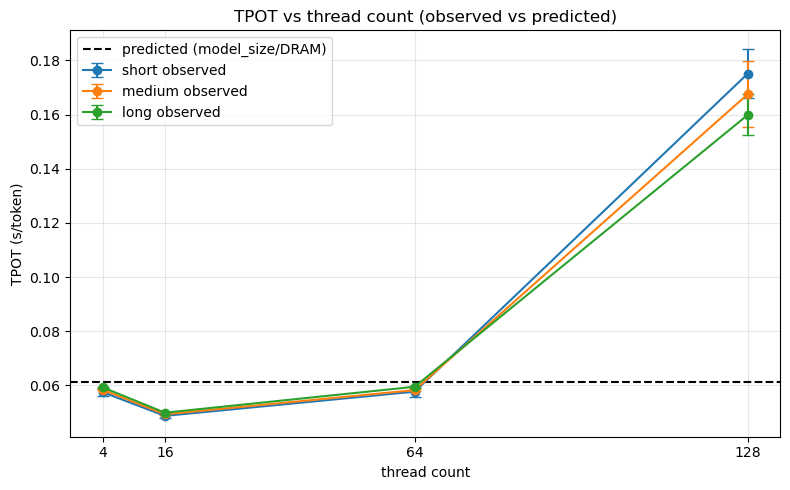

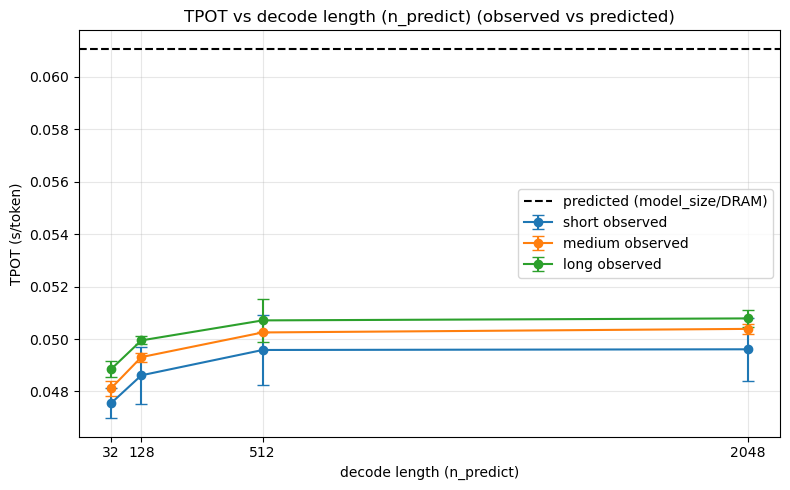

In [114]:
threads_tpot = _filter_categories("threads")
threads_tpot = threads_tpot.copy()
if not threads_tpot.empty:
    threads_tpot["tpot_s_predicted"] = predicted_tpot_s
display_plot_table(
    "TPOT vs thread count (observed/predicted)",
    threads_tpot,
    ["configuration_value", "category", "tpot_s_mean", "tpot_s_std", "tpot_s_predicted"],
)
plot_tpot_vs_config("threads", "thread count", "tpot_vs_thread_count.png")

decode_tpot = _filter_categories("decode_length")
decode_tpot = decode_tpot.copy()
if not decode_tpot.empty:
    decode_tpot["tpot_s_predicted"] = predicted_tpot_s
display_plot_table(
    "TPOT vs decode length (observed/predicted)",
    decode_tpot,
    ["configuration_value", "category", "tpot_s_mean", "tpot_s_std", "tpot_s_predicted"],
)
plot_tpot_vs_config("decode_length", "decode length (n_predict)", "tpot_vs_decode_length.png")

## Plot 1b: Prompt processing and generation vs. thread count

This companion plot shows TTFT as prompt processing and TPOT as generation across thread counts, using the same overall thread aggregation as the throughput chart.

,configuration_group,configuration_name,configuration_value,configuration_label,category,n_observations,n_prompts,n_workers,ttft_s_mean,ttft_s_std,ttft_s_mean_pm_std,tpot_s_mean,tpot_s_std,tpot_s_mean_pm_std,prompt_tps_mean,prompt_tps_std,prompt_tps_mean_pm_std,generation_tps_mean,generation_tps_std,generation_tps_mean_pm_std,peak_rss_mb_mean,peak_rss_mb_std,peak_rss_mb_mean_pm_std
0,threads,threads,4,threads=4,overall,93,31,0,3.769500,0.931510,3.769500 +/- 0.931510,0.058430,0.001060,0.058430 +/- 0.001060,45.998925,11.063930,45.998925 +/- 11.063930,17.120430,0.327892,17.120430 +/- 0.327892,3549.173639,172.370023,3549.173639 +/- 172.370023
1,threads,threads,16,threads=16,overall,93,31,0,3.148128,0.679026,3.148128 +/- 0.679026,0.049342,0.000702,0.049342 +/- 0.000702,94.769892,54.372717,94.769892 +/- 54.372717,20.270968,0.301655,20.270968 +/- 0.301655,3556.437080,177.406660,3556.437080 +/- 177.406660
2,threads,threads,64,threads=64,overall,93,31,0,3.055105,0.619124,3.055105 +/- 0.619124,0.058510,0.001421,0.058510 +/- 0.001421,114.341935,74.429970,114.341935 +/- 74.429970,17.102151,0.457065,17.102151 +/- 0.457065,3561.375630,178.114895,3561.375630 +/- 178.114895
3,threads,threads,128,threads=128,overall,93,31,0,3.279987,0.564210,3.279987 +/- 0.564210,0.167275,0.011545,0.167275 +/- 0.011545,64.643011,18.058290,64.643011 +/- 18.058290,6.004301,0.383891,6.004301 +/- 0.383891,3568.020833,180.517425,3568.020833 +/- 180.517425


Threads - TTFT/TPOT (s)


,configuration_value,category,ttft_s_mean,ttft_s_std,tpot_s_mean,tpot_s_std
0,4,short,2.651421,0.399148,0.057513,0.001323
1,4,medium,3.838511,0.461582,0.058400,0.000172
2,4,long,4.723199,0.206881,0.059290,0.000260
3,16,short,2.311899,0.359181,0.048741,0.000881
4,16,medium,3.333441,0.392075,0.049318,0.000153
5,16,long,3.739869,0.143168,0.049910,0.000150
6,64,short,2.286581,0.351270,0.057683,0.002071
7,64,medium,3.267337,0.375395,0.058254,0.000350
8,64,long,3.560825,0.052998,0.059493,0.000323
9,128,short,2.593920,0.338373,0.175136,0.009165


Saved data\experiments-x86\analysis_exports\plots\ttft_tpot_vs_thread_count.png


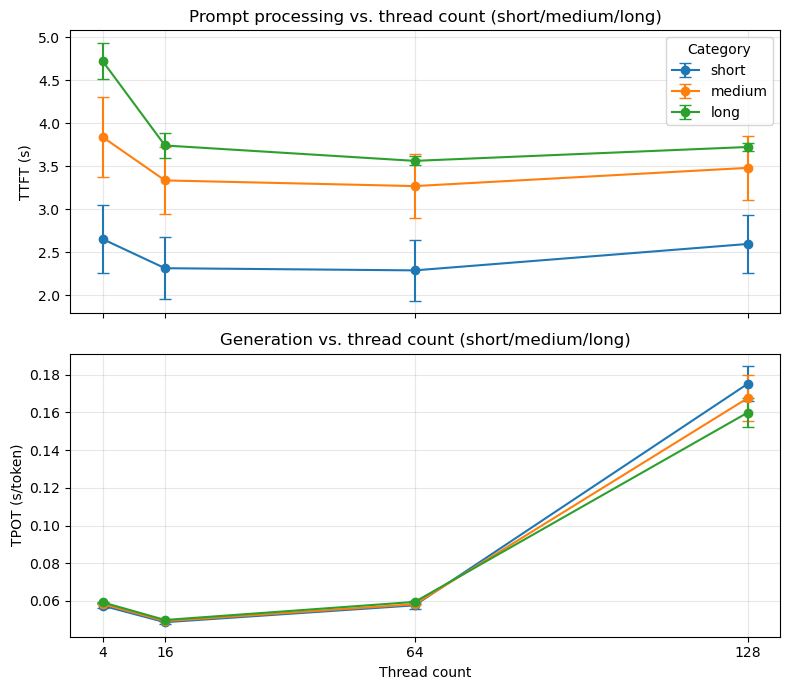

In [105]:
threads_overall = grouped_overall("threads")
display(threads_overall)

threads_cat = _filter_categories("threads")
display_plot_table(
    "Threads - TTFT/TPOT (s)",
    threads_cat,
    ["configuration_value", "category", "ttft_s_mean", "ttft_s_std", "tpot_s_mean", "tpot_s_std"],
)

xticks = _collect_xticks("threads")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 7))
plotted = False

for category in CATEGORIES:
    threads_cat = grouped_by_category("threads", category)
    if threads_cat.empty:
        print(f"No threads rows for category '{category}'; skipping TTFT/TPOT plot.")
        continue
    plot_df = threads_cat.dropna(subset=["configuration_value", "ttft_s_mean", "tpot_s_mean"]).copy()
    if plot_df.empty:
        print(f"No threads rows for category '{category}' after dropna; skipping TTFT/TPOT plot.")
        continue
    plot_df = _sort_by_x(plot_df, "configuration_value")
    color = CATEGORY_COLORS.get(category)

    axes[0].errorbar(
        plot_df["configuration_value"],
        plot_df["ttft_s_mean"],
        yerr=plot_df["ttft_s_std"].fillna(0),
        marker="o",
        capsize=4,
        linestyle="-",
        label=category,
        color=color,
    )
    axes[1].errorbar(
        plot_df["configuration_value"],
        plot_df["tpot_s_mean"],
        yerr=plot_df["tpot_s_std"].fillna(0),
        marker="o",
        capsize=4,
        linestyle="-",
        label=category,
        color=color,
    )
    plotted = True

if not plotted:
    warnings.warn("Skipping TTFT/TPOT vs. thread count; no category data.")
else:
    axes[0].set_ylabel("TTFT (s)")
    axes[0].set_title("Prompt processing vs. thread count (short/medium/long)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(title="Category")

    axes[1].set_ylabel("TPOT (s/token)")
    axes[1].set_xlabel("Thread count")
    axes[1].set_title("Generation vs. thread count (short/medium/long)")
    axes[1].grid(True, alpha=0.3)

    if xticks:
        for ax in axes:
            ax.set_xticks(xticks)
            ax.set_xticklabels([int(x) if float(x).is_integer() else x for x in xticks])

    save_current_plot("ttft_tpot_vs_thread_count.png")

## Diagnostic table

The plots above use the overall grouped rows. The table below helps check whether a configuration has enough observations per category for mean ± standard deviation to be meaningful.

In [106]:
cols = [
    "configuration_group", "configuration_label", "category", "n_observations", "n_prompts",
    "ttft_s_mean_pm_std", "tpot_s_mean_pm_std",
    "throughput_events_per_s_mean_pm_std", "peak_rss_mb_mean_pm_std",
]
cols = [c for c in cols if c in grouped.columns]
display(grouped[cols])

,configuration_group,configuration_label,category,n_observations,n_prompts,ttft_s_mean_pm_std,tpot_s_mean_pm_std,peak_rss_mb_mean_pm_std
0,concurrency,concurrency=2,short,20,10,5.958996 +/- 1.260902,0.182523 +/- 0.008462,3337.548438 +/- 110.076360
1,concurrency,concurrency=2,medium,20,10,8.557966 +/- 1.567303,0.181100 +/- 0.010677,3622.891211 +/- 110.106027
2,concurrency,concurrency=2,long,22,11,10.186809 +/- 1.630581,0.186616 +/- 0.012537,3673.935902 +/- 6.396845
3,concurrency,concurrency=2,overall,62,31,8.297565 +/- 2.297441,0.183516 +/- 0.010846,3548.957787 +/- 172.172852
4,concurrency,concurrency=4,short,40,10,17.613014 +/- 4.103089,1.477778 +/- 0.203783,3337.992383 +/- 108.151424
5,concurrency,concurrency=4,medium,40,10,22.769650 +/- 4.638798,1.313898 +/- 0.244932,3626.121484 +/- 109.760633
6,concurrency,concurrency=4,long,44,11,24.838775 +/- 4.569699,1.593211 +/- 0.316273,3678.036399 +/- 8.182885
7,concurrency,concurrency=4,overall,124,31,21.840424 +/- 5.363739,1.465873 +/- 0.283754,3551.598034 +/- 172.959839
8,concurrency,concurrency=16,short,16,1,201.446999 +/- 19.224167,NaN,3300.910889 +/- 1.901222
9,concurrency,concurrency=16,overall,16,1,201.446999 +/- 19.224167,NaN,3300.910889 +/- 1.901222


In [107]:
print("Plot outputs:")
for path in sorted(PLOTS_DIR.glob("*.png")):
    print(path)
print("Prediction CSV:")
print(prediction_csv if 'prediction_csv' in globals() else "Not created")

Plot outputs:
data\experiments-x86\analysis_exports\plots\generation_tps_vs_concurrency.png
data\experiments-x86\analysis_exports\plots\generation_tps_vs_thread_count.png
data\experiments-x86\analysis_exports\plots\peak_rss_vs_decode_length.png
data\experiments-x86\analysis_exports\plots\peak_rss_vs_prompt_length.png
data\experiments-x86\analysis_exports\plots\peak_rss_vs_thread_count.png
data\experiments-x86\analysis_exports\plots\predicted_vs_observed_tpot.png
data\experiments-x86\analysis_exports\plots\prompt_tps_vs_concurrency.png
data\experiments-x86\analysis_exports\plots\prompt_tps_vs_thread_count.png
data\experiments-x86\analysis_exports\plots\throughput_vs_concurrency.png
data\experiments-x86\analysis_exports\plots\throughput_vs_concurrency_long.png
data\experiments-x86\analysis_exports\plots\throughput_vs_concurrency_medium.png
data\experiments-x86\analysis_exports\plots\throughput_vs_concurrency_short.png
data\experiments-x86\analysis_exports\plots\throughput_vs_thread_count